# Predicting Product Reorder Behavior Using Instacart Grocery Transaction Data

## Capstone Project

### Overview

This capstone project focuses on developing a machine learning framework to predict whether a customer will reorder a previously purchased grocery product using historical Instacart transaction data. The objective is to model customer purchasing behavior and demonstrate how predictive analytics can support product retention and personalization strategies in online grocery retail.

The project is structured as a supervised binary classification task where the target variable is:

- **reordered**
  - 0 = Product not reordered
  - 1 = Product reordered

This project follows a structured data science pipeline:
1. Data Cleaning & Preparation
2. Exploratory Data Analysis  
3. Feature Engineering
4. Exploratory Data Analysis of Engineered Features
5. Model Development  
6. Model Evaluation  
7. Business Interpretation & Deployment  


# Introduction

## Business Context

Instacart is an online grocery delivery platform that allows customers to order groceries from partner retailers. One of the most critical business challenges in e-commerce grocery retail is predicting which products a customer is likely to reorder.

Accurate reorder prediction enables:

- Personalized recommendations
- Optimized inventory planning
- Improved customer retention
- Targeted promotions
- Increased basket size

Understanding reorder behavior provides measurable business value and competitive advantage.

---

## Dataset Overview

This project utilizes the **Instacart Market Basket Analysis Dataset** available on Kaggle.

Dataset Source:
https://www.kaggle.com/datasets/psparks/instacart-market-basket-analysis

The dataset contains anonymized order history for over 200,000 users and includes the following core files:

- orders.csv  
- order_products__prior.csv  
- order_products__train.csv  
- products.csv  
- aisles.csv  
- departments.csv  

### Key Characteristics

- Over 3 million grocery orders
- Millions of product-level transactions
- User purchase history over time
- Reorder indicators for each product in each order

This rich transactional dataset longituinal enables modeling of customer-product interaction patterns.

---

## Problem Statement

The objective of this project is to develop a machine learning model that predicts whether a customer will reorder a previously purchased product.

### Target Variable

reordered:
- 1 → Product reordered
- 0 → Product not reordered

### Modeling Objective

Binary Classification

### Analytical Scope

- One company: Instacart  
- One objective: Predict product reorders  
- One modeling goal: Binary classification  
- One deployment tool (future phase): Dash  

This focused scope ensures clarity, measurability, and academic rigor.

In [1]:
# ============================================
# Import Libraries
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, zipfile, glob

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

RANDOM_STATE = 42

## Data Ingestion and Preparation

All relevant data files are loaded and merged to construct structured analytical tables. Prior orders are used for feature engineering to prevent data leakage.

In [2]:
# Upload the .zip file

from google.colab import files

uploaded = files.upload()
zip_name = next(iter(uploaded))
print("Uploaded:", zip_name)

Saving Instacart.zip to Instacart.zip
Uploaded: Instacart.zip


In [3]:
# Unzip into /content and detect data directory

# Unzip
with zipfile.ZipFile(zip_name, "r") as z:
    z.extractall("/content")

print("Unzipped to /content")

# Try to auto-detect where the CSVs are
required = {
    "orders.csv",
    "order_products__prior.csv",
    "order_products__train.csv",
    "products.csv",
    "aisles.csv",
    "departments.csv"
}

# Search for orders.csv and infer folder
candidates = glob.glob("/content/**/orders.csv", recursive=True)

if not candidates:
    raise FileNotFoundError("orders.csv not found after unzip. Check the zip structure.")

# Pick the first match (usually correct)
DATA_DIR = os.path.dirname(candidates[0])

# Validate required files exist in that directory
found = set(os.listdir(DATA_DIR))
missing = required - found
if missing:
    raise FileNotFoundError(f"Missing files in DATA_DIR={DATA_DIR}: {missing}")

print("DATA_DIR set to:", DATA_DIR)
print("Files found:", sorted(required))

Unzipped to /content
DATA_DIR set to: /content
Files found: ['aisles.csv', 'departments.csv', 'order_products__prior.csv', 'order_products__train.csv', 'orders.csv', 'products.csv']


In [4]:
# Load reduced columns + optimize memory


# Helper: Memory Optimization
def optimize_df(df: pd.DataFrame) -> pd.DataFrame:
    """Downcast numeric columns to reduce RAM usage."""
    try:
        for col in df.select_dtypes(include=["int64"]).columns:
            df[col] = pd.to_numeric(df[col], downcast="integer")
        for col in df.select_dtypes(include=["float64"]).columns:
            df[col] = pd.to_numeric(df[col], downcast="float")
        return df
    except Exception as e:
        raise RuntimeError(f"Memory optimization failed: {e}")

# Helper: Safe CSV Reader
def safe_read_csv(path: str, usecols: list, name: str) -> pd.DataFrame:
    """
    Read CSV with exception handling and clear error messages.
    - Ensures file exists
    - Ensures required columns exist
    """
    if not os.path.exists(path):
        raise FileNotFoundError(f"[{name}] File not found: {path}")

    try:
        df = pd.read_csv(path, usecols=usecols)
    except ValueError as e:
        # Commonly: Usecols do not match columns
        raise ValueError(f"[{name}] Column mismatch when reading {path}. "
                         f"Expected columns: {usecols}. Original error: {e}")
    except pd.errors.ParserError as e:
        raise pd.errors.ParserError(f"[{name}] CSV parsing error for {path}: {e}")
    except Exception as e:
        raise RuntimeError(f"[{name}] Unexpected error reading {path}: {e}")

    # Validate expected columns after load
    missing_cols = set(usecols) - set(df.columns)
    if missing_cols:
        raise ValueError(f"[{name}] Missing expected columns after loading: {missing_cols}")

    return df


# Validate DATA_DIR
try:
    if "DATA_DIR" not in globals() or DATA_DIR is None:
        raise ValueError("DATA_DIR is not defined. Run the unzip + auto-detect cell first.")

    if not os.path.isdir(DATA_DIR):
        raise NotADirectoryError(f"DATA_DIR is not a valid directory: {DATA_DIR}")

    print("Using DATA_DIR:", DATA_DIR)

except Exception as e:
    raise RuntimeError(f"DATA_DIR validation failed: {e}")


# Required files + load configs
files_config = {
    "orders": {
        "filename": "orders.csv",
        "usecols": ["order_id","user_id","eval_set","order_number","order_dow","order_hour_of_day","days_since_prior_order"]
    },
    "order_products_prior": {
        "filename": "order_products__prior.csv",
        "usecols": ["order_id","product_id","add_to_cart_order","reordered"]
    },
    "order_products_train": {
        "filename": "order_products__train.csv",
        "usecols": ["order_id","product_id","add_to_cart_order","reordered"]
    },
    "products": {
        "filename": "products.csv",
        "usecols": ["product_id","aisle_id","department_id"]  # product_name intentionally dropped for RAM
    },
    "aisles": {
        "filename": "aisles.csv",
        "usecols": ["aisle_id","aisle"]
    },
    "departments": {
        "filename": "departments.csv",
        "usecols": ["department_id","department"]
    }
}


# Load datasets safely
try:
    orders = safe_read_csv(os.path.join(DATA_DIR, files_config["orders"]["filename"]),
                           files_config["orders"]["usecols"], "orders")
    orders = optimize_df(orders)
    orders["eval_set"] = orders["eval_set"].astype("category")

    order_products_prior = safe_read_csv(os.path.join(DATA_DIR, files_config["order_products_prior"]["filename"]),
                                         files_config["order_products_prior"]["usecols"], "order_products_prior")
    order_products_prior = optimize_df(order_products_prior)

    order_products_train = safe_read_csv(os.path.join(DATA_DIR, files_config["order_products_train"]["filename"]),
                                         files_config["order_products_train"]["usecols"], "order_products_train")
    order_products_train = optimize_df(order_products_train)

    products = safe_read_csv(os.path.join(DATA_DIR, files_config["products"]["filename"]),
                             files_config["products"]["usecols"], "products")
    products = optimize_df(products)

    aisles = safe_read_csv(os.path.join(DATA_DIR, files_config["aisles"]["filename"]),
                           files_config["aisles"]["usecols"], "aisles")
    aisles = optimize_df(aisles)

    departments = safe_read_csv(os.path.join(DATA_DIR, files_config["departments"]["filename"]),
                                files_config["departments"]["usecols"], "departments")
    departments = optimize_df(departments)

except Exception as e:
    raise RuntimeError(f"Dataset loading failed: {e}")


# Final sanity checks
try:
    # Basic integrity checks
    if orders.empty or order_products_prior.empty or order_products_train.empty:
        raise ValueError("One or more loaded DataFrames are empty. Check CSV contents / paths.")

    # Check eval_set expected values
    allowed_eval = {"prior", "train", "test"}
    observed_eval = set(orders["eval_set"].astype(str).unique())
    if not observed_eval.issubset(allowed_eval):
        raise ValueError(f"Unexpected eval_set values found: {observed_eval - allowed_eval}")

except Exception as e:
    raise RuntimeError(f"Post-load validation failed: {e}")

# Confirm successful load
print("Loaded shapes:")
print("orders:", orders.shape)
print("prior lines:", order_products_prior.shape)
print("train lines:", order_products_train.shape)
print("products:", products.shape)
print("aisles:", aisles.shape)
print("departments:", departments.shape)

Using DATA_DIR: /content
Loaded shapes:
orders: (3421083, 7)
prior lines: (32434489, 4)
train lines: (1384617, 4)
products: (49688, 3)
aisles: (134, 2)
departments: (21, 2)


In [5]:
# User Sampling

N_USERS = 400000
RANDOM_STATE = 42

rng = np.random.default_rng(RANDOM_STATE)
all_users = orders["user_id"].unique()

if N_USERS > len(all_users):
    N_USERS = len(all_users)

sample_users = rng.choice(all_users, size=N_USERS, replace=False)

orders_small = orders[orders["user_id"].isin(sample_users)].copy()

print("Sampled users:", N_USERS)
print("orders_small:", orders_small.shape)
print("eval_set counts:\n", orders_small["eval_set"].value_counts())

Sampled users: 206209
orders_small: (3421083, 7)
eval_set counts:
 eval_set
prior    3214874
train     131209
test       75000
Name: count, dtype: int64


In [6]:
# Filter line-items to sampled order_ids

# Only keep order_ids from sampled users
prior_order_ids = orders_small.loc[orders_small["eval_set"]=="prior", "order_id"]
train_order_ids = orders_small.loc[orders_small["eval_set"]=="train", "order_id"]

# Filter line-item tables
order_products_prior_small = order_products_prior[order_products_prior["order_id"].isin(prior_order_ids)].copy()
order_products_train_small = order_products_train[order_products_train["order_id"].isin(train_order_ids)].copy()

print("order_products_prior_small:", order_products_prior_small.shape)
print("order_products_train_small:", order_products_train_small.shape)

order_products_prior_small: (32434489, 4)
order_products_train_small: (1384617, 4)


In [7]:
# Merge product hierarchy + build prior/train merged tables

# Product hierarchy (small)
products_dim = (
    products
    .merge(aisles, on="aisle_id", how="left")
    .merge(departments, on="department_id", how="left")
)

orders_prior = orders_small[orders_small["eval_set"]=="prior"]
orders_train = orders_small[orders_small["eval_set"]=="train"]

# Build merged tables
prior = (
    order_products_prior_small
    .merge(orders_prior, on="order_id", how="left")
    .merge(products_dim, on="product_id", how="left")
)

train_data = (
    order_products_train_small
    .merge(orders_train, on="order_id", how="left")
    .merge(products_dim, on="product_id", how="left")
)

print("products_dim:", products_dim.shape)
print("prior:", prior.shape)
print("train_data:", train_data.shape)

prior.head()

products_dim: (49688, 5)
prior: (32434489, 14)
train_data: (1384617, 14)


,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,aisle_id,department_id,aisle,department
0,2,33120,1,1,202279,prior,3,5,9,8.0,86,16,eggs,dairy eggs
1,2,28985,2,1,202279,prior,3,5,9,8.0,83,4,fresh vegetables,produce
2,2,9327,3,0,202279,prior,3,5,9,8.0,104,13,spices seasonings,pantry
3,2,45918,4,1,202279,prior,3,5,9,8.0,19,13,oils vinegars,pantry
4,2,30035,5,0,202279,prior,3,5,9,8.0,17,13,baking ingredients,pantry


## Exploratory Data Analysis

Exploratory Data Analysis (EDA) is conducted to understand reorder behavior, purchasing intensity, and category-level patterns in the Instacart transaction data. This step provides statistical insight and business intuition prior to feature engineering and model development.

The analysis focuses on:
- Target distribution and class imbalance
- Ordering frequency and temporal trends
- Category-level purchase concentration
- Reorder behavior across departments and aisles

In [8]:
# Target distribution

print("Target distribution in training orders (train_data):")
display(train_data["reordered"].value_counts())
display(train_data["reordered"].value_counts(normalize=True).round(4))

Target distribution in training orders (train_data):


,count
reordered,
1,828824
0,555793


,proportion
reordered,
1,0.5986
0,0.4014


### Ordering Frequency per User

User order counts are examined to understand engagement intensity and variation across customers.

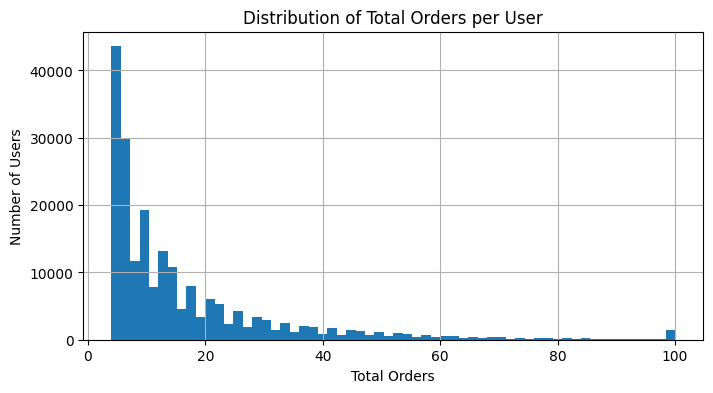

Mean total orders per user: 16.59
Median total orders per user: 10.0


In [9]:
# Orders per user histogram

orders_per_user = orders.groupby("user_id")["order_number"].max()

plt.figure(figsize=(8,4))
orders_per_user.hist(bins=60)
plt.title("Distribution of Total Orders per User")
plt.xlabel("Total Orders")
plt.ylabel("Number of Users")
plt.show()

print("Mean total orders per user:", round(orders_per_user.mean(), 2))
print("Median total orders per user:", round(orders_per_user.median(), 2))

### Distribution of Orders per User

This histogram shows the distribution of the total number of orders placed by each user. The distribution is right-skewed, indicating that most users place a relatively small number of orders, while a smaller group of highly active users place many orders. The mean and median values provide additional context about typical user activity. Understanding this behavior is important because users with more historical orders provide richer behavioral signals for predicting reorder patterns.

### Shopping Time Patterns

Temporal purchase trends are evaluated using hour-of-day and day-of-week distributions.

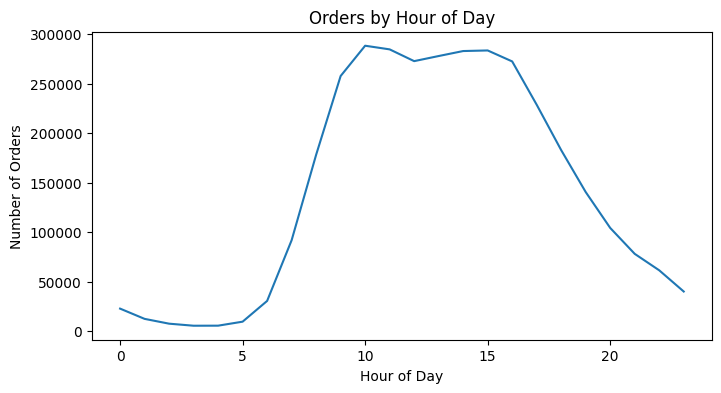

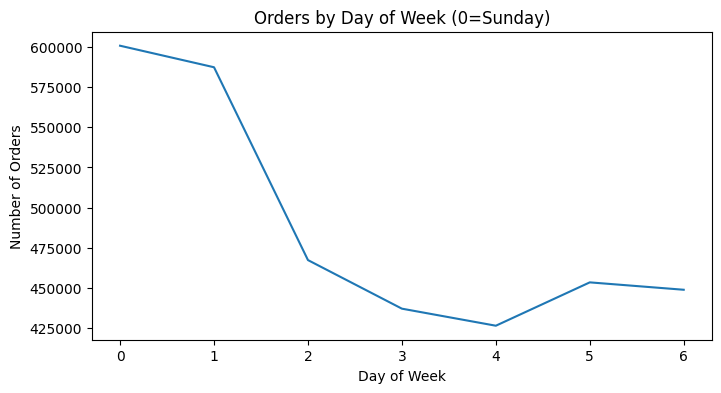

In [10]:
# Temporal plots

plt.figure(figsize=(8,4))
orders["order_hour_of_day"].value_counts().sort_index().plot()
plt.title("Orders by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")
plt.show()

plt.figure(figsize=(8,4))
orders["order_dow"].value_counts().sort_index().plot()
plt.title("Orders by Day of Week (0=Sunday)")
plt.xlabel("Day of Week")
plt.ylabel("Number of Orders")
plt.show()

### Orders by Hour of Day

This plot shows how orders are distributed throughout the day. Most orders occur during daytime hours, with peaks typically occurring in the late morning and evening periods. This pattern reflects normal consumer shopping behavior, where customers are more likely to place grocery orders during waking hours rather than overnight. Temporal patterns like this can provide useful context for understanding when purchasing activity is most concentrated.

### Orders by Day of Week

This visualization shows how order activity varies across the days of the week. Certain days have noticeably higher order volumes, suggesting that customers tend to place grocery orders more frequently on specific days, such as weekends or early in the week. Identifying these patterns helps provide insight into typical shopping cycles and weekly purchasing behavior.

### Category Concentration

Department-level purchase volumes and reorder rates provide high-level insight into consumer behavior.

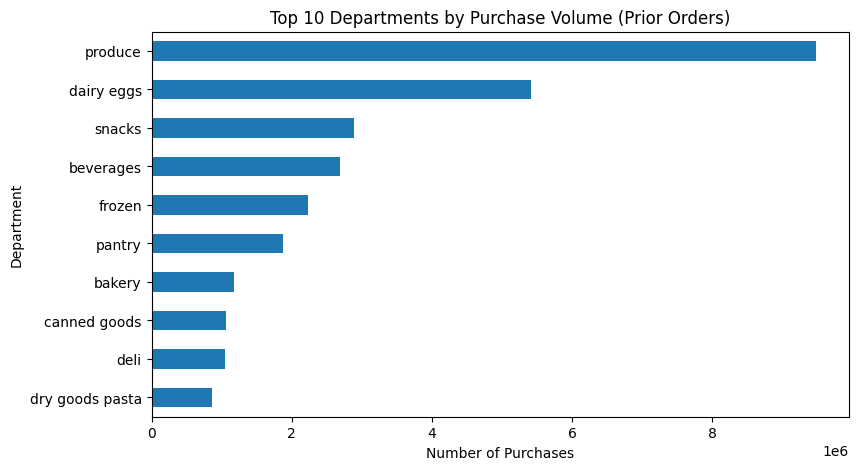

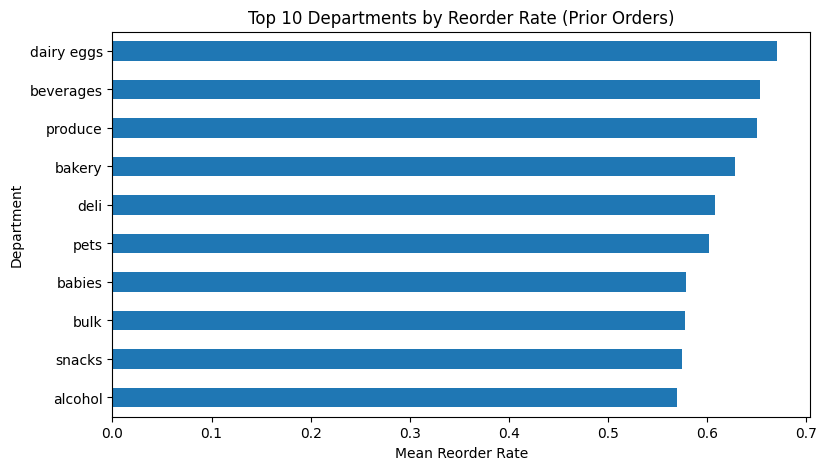

In [11]:
# Top departments + reorder rates

dept_volume = prior.groupby("department")["product_id"].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(9,5))
dept_volume.sort_values().plot(kind="barh")
plt.title("Top 10 Departments by Purchase Volume (Prior Orders)")
plt.xlabel("Number of Purchases")
plt.ylabel("Department")
plt.show()

dept_reorder_rate = prior.groupby("department")["reordered"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(9,5))
dept_reorder_rate.sort_values().plot(kind="barh")
plt.title("Top 10 Departments by Reorder Rate (Prior Orders)")
plt.xlabel("Mean Reorder Rate")
plt.ylabel("Department")
plt.show()

### Top Departments by Purchase Volume

This chart displays the departments with the highest number of purchases in prior orders. Departments such as produce, dairy, and snacks tend to dominate purchase volume, indicating that these categories represent frequently purchased grocery staples. High-volume departments are particularly important in reorder prediction because customers often repeatedly purchase items within these categories.

### Top Departments by Reorder Rate

This visualization shows the departments with the highest average reorder rates. A higher reorder rate indicates that products in that department are frequently purchased again by customers. Categories with high reorder rates typically include everyday essentials such as produce or dairy, where customers repeatedly buy similar items over time. This reinforces the importance of modeling customer loyalty and purchase frequency when predicting reorder behavior.

## Feature Engineering

Predictive features are engineered using prior order history only to avoid target leakage. Features are constructed at three levels:

- User-level behavior features
- Product-level behavior features
- User–product interaction features

These features are merged onto the labeled user–product pairs in the training set to create the modeling dataset.

In [12]:
# User-level features

user_features = prior.groupby("user_id").agg(
    user_total_orders=("order_number", "max"),
    user_avg_days_between=("days_since_prior_order", "mean"),
    user_reorder_ratio=("reordered", "mean"),
    user_total_items=("product_id", "count"),
    user_distinct_products=("product_id", pd.Series.nunique),
).reset_index()

user_features["user_avg_days_between"] = user_features["user_avg_days_between"].fillna(0)

print("user_features:", user_features.shape)
user_features.head()

user_features: (206209, 6)


,user_id,user_total_orders,user_avg_days_between,user_reorder_ratio,user_total_items,user_distinct_products
0,1,10,20.259260,0.694915,59,18
1,2,14,15.967033,0.476923,195,102
2,3,12,11.487180,0.625000,88,33
3,4,5,15.357142,0.055556,18,17
4,5,4,14.500000,0.378378,37,23


In [13]:
# Product-level features

product_features = prior.groupby("product_id").agg(
    product_popularity=("user_id", "count"),
    product_reorder_rate=("reordered", "mean"),
    product_distinct_users=("user_id", pd.Series.nunique),
).reset_index()

print("product_features:", product_features.shape)
product_features.head()

product_features: (49677, 4)


,product_id,product_popularity,product_reorder_rate,product_distinct_users
0,1,1852,0.613391,716
1,2,90,0.133333,78
2,3,277,0.732852,74
3,4,329,0.446809,182
4,5,15,0.600000,6


In [14]:
# User–Product features + recency

user_product_features = prior.groupby(["user_id", "product_id"]).agg(
    times_user_bought_product=("order_id", "count"),
    user_product_reorder_rate=("reordered", "mean"),
    last_order_number_user_bought_product=("order_number", "max"),
    first_order_number_user_bought_product=("order_number", "min"),
).reset_index()

user_last_prior_order = prior.groupby("user_id").agg(
    user_last_prior_order=("order_number", "max")
).reset_index()

user_product_features = user_product_features.merge(user_last_prior_order, on="user_id", how="left")

user_product_features["orders_since_last_purchase"] = (
    user_product_features["user_last_prior_order"] - user_product_features["last_order_number_user_bought_product"]
)

user_product_features.drop(columns=["user_last_prior_order"], inplace=True)

print("user_product_features:", user_product_features.shape)
user_product_features.head()

user_product_features: (13307953, 7)


,user_id,product_id,times_user_bought_product,user_product_reorder_rate,last_order_number_user_bought_product,first_order_number_user_bought_product,orders_since_last_purchase
0,1,196,10,0.900000,10,1,0
1,1,10258,9,0.888889,10,2,0
2,1,10326,1,0.000000,5,5,5
3,1,12427,10,0.900000,10,1,0
4,1,13032,3,0.666667,10,2,0


## Feature Assembly for Modeling

Engineered user-level, product-level, and user–product interaction features are merged onto the candidate set. Missing values are imputed with neutral defaults.

### Correct Label Construction (Candidate Generation)

A correct modeling dataset requires generating candidate user–product pairs from historical (prior) purchases and labeling whether each candidate product appears in the user’s subsequent training order.

This approach prevents selection bias that occurs when using only products present in the training order and ensures the supervised task reflects a realistic reorder prediction problem.

In [15]:
# Candidate pairs from PRIOR

# All products a user has EVER purchased before (historical candidates)
candidate_pairs = prior[["user_id", "product_id"]].drop_duplicates()

print("candidate_pairs:", candidate_pairs.shape)

# True labels from TRAIN

# Products in the user's train order; reordered indicates whether it was a reorder
train_labels = train_data[["user_id", "product_id", "reordered"]].copy()

print("train_labels:", train_labels.shape)

# Build correct label table

# Left join: candidate pairs that appear in train get reordered label
# Candidate pairs not in train are labeled 0
model_df = candidate_pairs.merge(
    train_labels,
    on=["user_id", "product_id"],
    how="left"
)

model_df["reordered"] = model_df["reordered"].fillna(0).astype(int)

print("model_df (candidates + labels):", model_df.shape)
print("Target distribution:")
print(model_df["reordered"].value_counts())
print(model_df["reordered"].value_counts(normalize=True).round(4))

candidate_pairs: (13307953, 2)
train_labels: (1384617, 3)
model_df (candidates + labels): (13307953, 3)
Target distribution:
reordered
0    12479129
1      828824
Name: count, dtype: int64
reordered
0    0.9377
1    0.0623
Name: proportion, dtype: float64


In [16]:
# Merge engineered features
model_df = (
    model_df
    .merge(user_features, on="user_id", how="left")
    .merge(product_features, on="product_id", how="left")
    .merge(user_product_features, on=["user_id", "product_id"], how="left")
)

# Fill missing values (neutral defaults)
fill_zero_cols = [
    "times_user_bought_product",
    "user_product_reorder_rate",
    "last_order_number_user_bought_product",
    "first_order_number_user_bought_product",
    "orders_since_last_purchase",
    "product_popularity",
    "product_reorder_rate",
    "product_distinct_users",
    "user_total_orders",
    "user_avg_days_between",
    "user_reorder_ratio",
    "user_total_items",
    "user_distinct_products",
]

for c in fill_zero_cols:
    if c in model_df.columns:
        model_df[c] = model_df[c].fillna(0)

print("Final model_df shape (with features):", model_df.shape)
model_df.head()

Final model_df shape (with features): (13307953, 16)


,user_id,product_id,reordered,user_total_orders,user_avg_days_between,user_reorder_ratio,user_total_items,user_distinct_products,product_popularity,product_reorder_rate,product_distinct_users,times_user_bought_product,user_product_reorder_rate,last_order_number_user_bought_product,first_order_number_user_bought_product,orders_since_last_purchase
0,202279,33120,1,8,21.862499,0.477778,90,47,19400,0.708454,5656,5,0.800000,8,1,0
1,202279,28985,0,8,21.862499,0.477778,90,47,67449,0.694465,20608,5,0.800000,6,1,2
2,202279,9327,0,8,21.862499,0.477778,90,47,6299,0.157962,5304,1,0.000000,3,3,5
3,202279,45918,0,8,21.862499,0.477778,90,47,744,0.272849,541,5,0.800000,7,2,1
4,202279,30035,0,8,21.862499,0.477778,90,47,569,0.507909,280,3,0.666667,7,3,1


## Exploratory Data Analysis of Engineered Features

After feature engineering, the engineered variables are evaluated to confirm that they capture meaningful behavioral patterns and to assess their relationship with the target variable. This step improves interpretability and provides justification for the selected modeling approach.

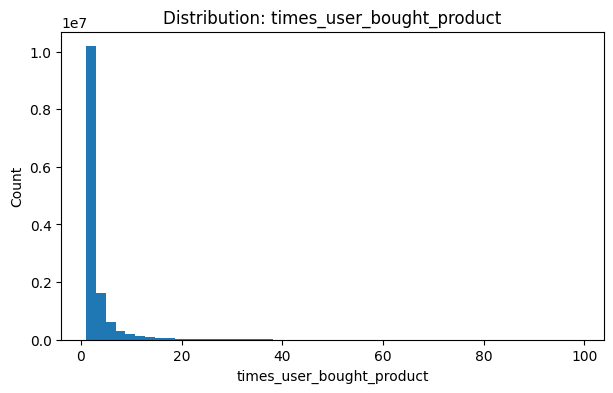

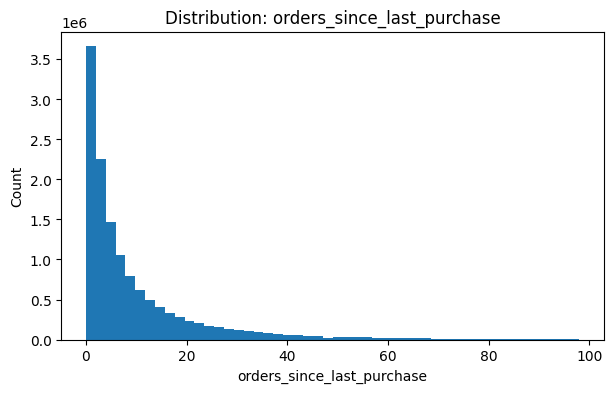

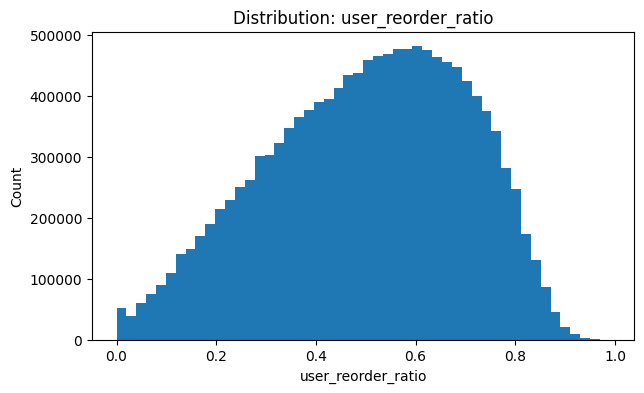

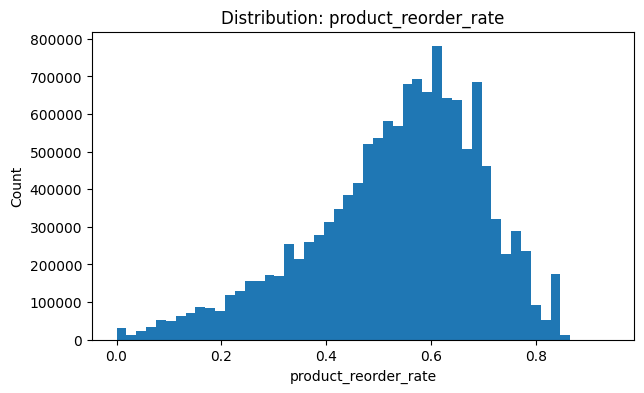

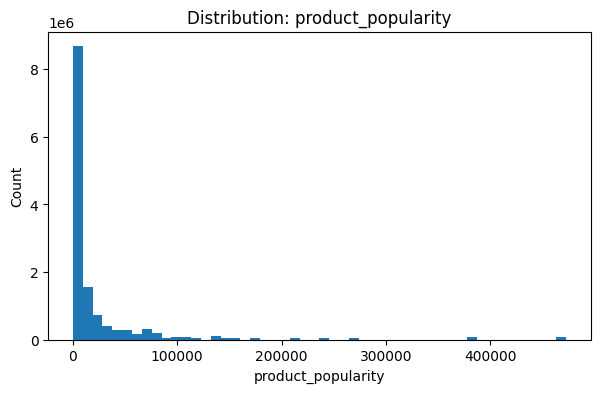

In [17]:
# Distributions

key_features = [
    "times_user_bought_product",
    "orders_since_last_purchase",
    "user_reorder_ratio",
    "product_reorder_rate",
    "product_popularity"
]

for f in key_features:
    if f in model_df.columns:
        plt.figure(figsize=(7,4))
        model_df[f].plot(kind="hist", bins=50)
        plt.title(f"Distribution: {f}")
        plt.xlabel(f)
        plt.ylabel("Count")
        plt.show()

### Distribution of Engineered Features

These histograms show the distribution of key engineered features used in the model. Most variables are highly right-skewed, meaning that a large number of user–product pairs have low values while a smaller number have very high values. For example, most products are purchased only a few times by a given user, while a smaller subset of products are purchased repeatedly. This behavior reflects typical consumer shopping patterns where customers regularly reorder a small set of favorite products.

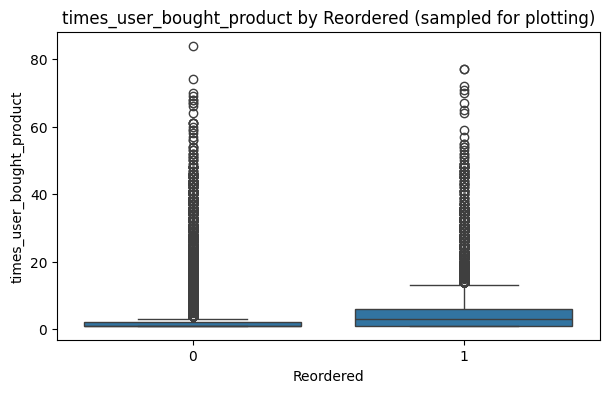

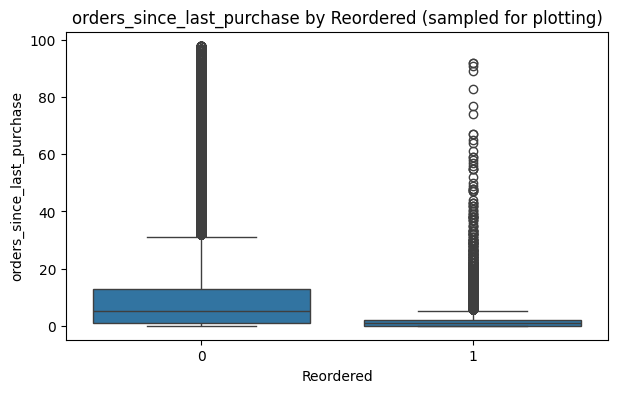

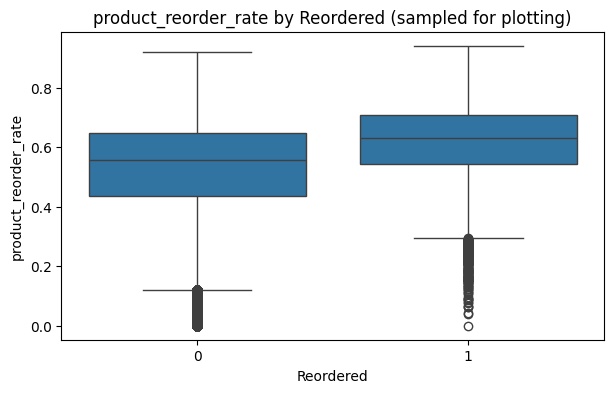

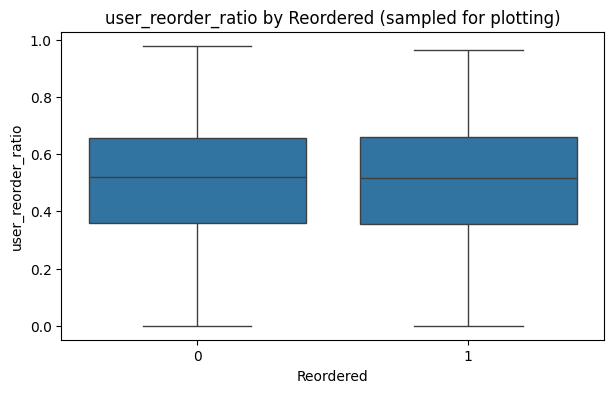

In [18]:
# Feature vs Target (boxplots)

for f in ["times_user_bought_product", "orders_since_last_purchase", "product_reorder_rate", "user_reorder_ratio"]:
    if f in model_df.columns:
        plt.figure(figsize=(7,4))
        sns.boxplot(x="reordered", y=f, data=model_df.sample(200000, random_state=RANDOM_STATE))
        plt.title(f"{f} by Reordered (sampled for plotting)")
        plt.xlabel("Reordered")
        plt.ylabel(f)
        plt.show()

### Feature Behavior by Reorder Outcome

These boxplots compare the distribution of key features for products that were reordered versus those that were not. Products that were reordered generally show higher purchase frequency and higher reorder-related metrics. This suggests that features such as purchase count and reorder rate are strong indicators of future reorder behavior. Visualizing these differences helps confirm that the engineered features are informative for predicting the target variable.

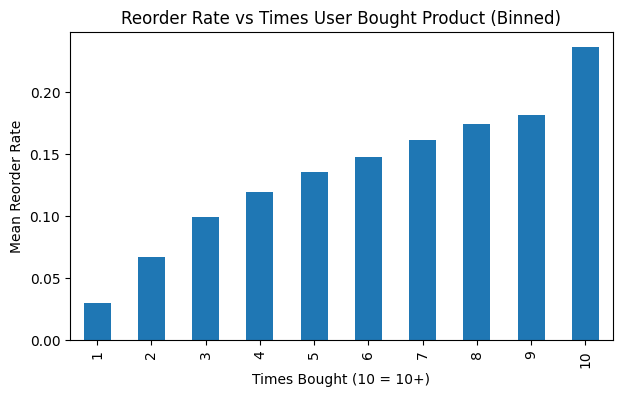

,reordered
purchase_bin,
1,0.029968
2,0.066777
3,0.099130
4,0.119271
5,0.135589
6,0.147332
7,0.161322
8,0.173775
9,0.181210


In [19]:
# Binned Reorder Rate vs Purchase Count

tmp = model_df[["times_user_bought_product", "reordered"]].copy()

# Bin purchase counts (cap at 10+ to keep it readable)
tmp["purchase_bin"] = tmp["times_user_bought_product"].clip(0, 10)
tmp["purchase_bin"] = tmp["purchase_bin"].astype(int)

reorder_by_bin = tmp.groupby("purchase_bin")["reordered"].mean()

plt.figure(figsize=(7,4))
reorder_by_bin.plot(kind="bar")
plt.title("Reorder Rate vs Times User Bought Product (Binned)")
plt.xlabel("Times Bought (10 = 10+)")
plt.ylabel("Mean Reorder Rate")
plt.show()

reorder_by_bin

### Reorder Probability vs Purchase Frequency

This plot shows how the probability of a reorder changes as the number of times a user has previously purchased a product increases. The reorder rate rises steadily as purchase frequency increases, indicating that products bought multiple times are significantly more likely to be reordered again. This pattern highlights the importance of customer loyalty and purchase frequency as key predictors in the reorder prediction model.

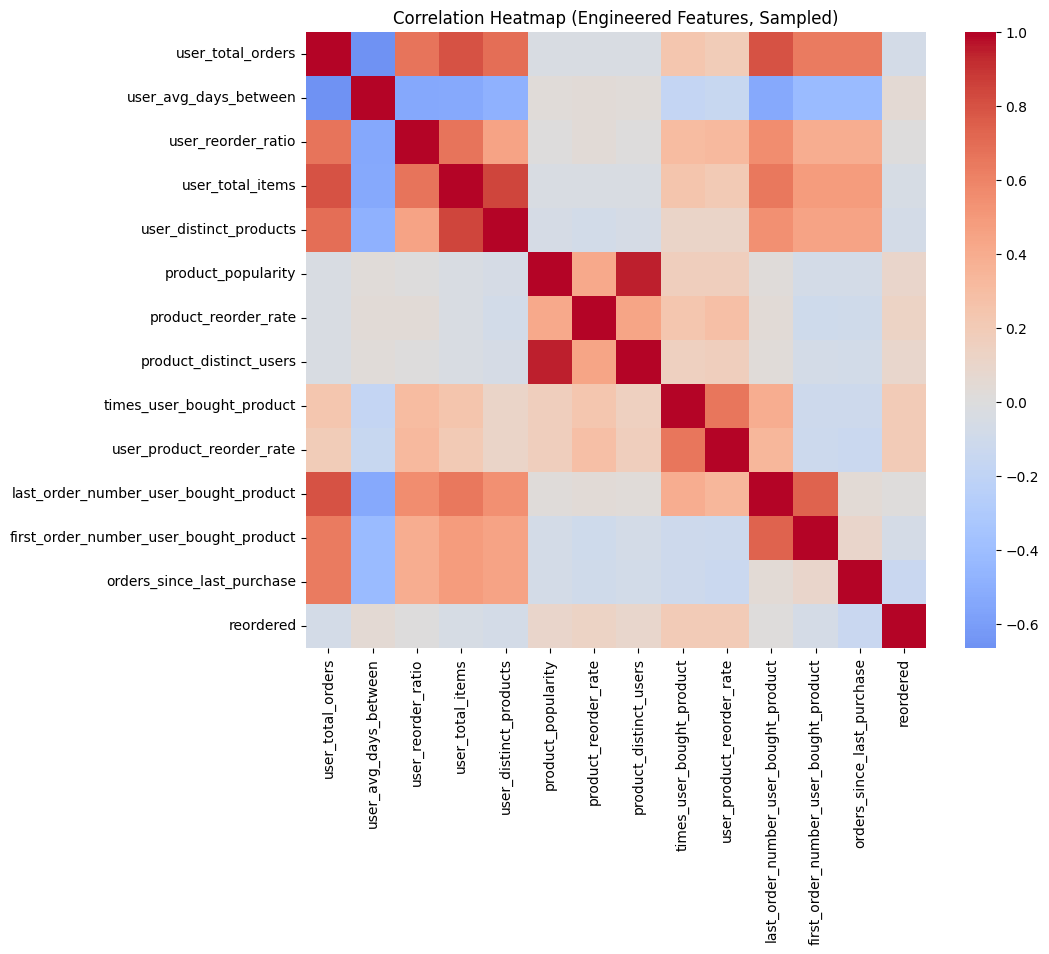

In [20]:
# Correlation Heatmap (use sample to avoid heavy RAM)

numeric_cols = [c for c in model_df.columns if c not in ["user_id","product_id","reordered"]]
sample_corr = model_df[numeric_cols + ["reordered"]].sample(200000, random_state=RANDOM_STATE)

corr = sample_corr.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Engineered Features, Sampled)")
plt.show()

### Correlation Between Engineered Features

The correlation heatmap illustrates relationships between the engineered features and the target variable. Several features show positive relationships with reorder behavior, particularly those related to purchase frequency and reorder history. While some features are moderately correlated with each other, most correlations remain relatively low, indicating that the features capture different aspects of user purchasing behavior. This diversity of signals is beneficial for machine learning models such as Random Forest that can combine multiple behavioral patterns to improve predictions.

## Model Development

The modeling dataset is split into training and validation sets with stratification to preserve the reorder distribution. A baseline Logistic Regression model is trained first for interpretability, followed by a Random Forest model to capture non-linear relationships.

Performance is evaluated using:
- ROC-AUC
- Precision, Recall, F1-score
- Confusion matrix
- ROC curve

In [21]:
# Train/Val split

X = model_df.drop(columns=["user_id", "product_id", "reordered"])
y = model_df["reordered"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train:", X_train.shape, "Validation:", X_val.shape)
print("Train reorder rate:", round(y_train.mean(), 4), "Val reorder rate:", round(y_val.mean(), 4))

Train: (10646362, 13) Validation: (2661591, 13)
Train reorder rate: 0.0623 Val reorder rate: 0.0623


In [22]:
# Baseline Logistic Regression

log_model = LogisticRegression(max_iter=1000, n_jobs=-1)
log_model.fit(X_train, y_train)

log_probs = log_model.predict_proba(X_val)[:, 1]
log_preds = (log_probs >= 0.5).astype(int)

print("Logistic Regression ROC-AUC:", round(roc_auc_score(y_val, log_probs), 4))
print(classification_report(y_val, log_preds, digits=4))

Logistic Regression ROC-AUC: 0.7622
              precision    recall  f1-score   support

           0     0.9391    0.9976    0.9675   2495826
           1     0.4224    0.0261    0.0491    165765

    accuracy                         0.9371   2661591
   macro avg     0.6807    0.5119    0.5083   2661591
weighted avg     0.9069    0.9371    0.9103   2661591



### Logistic Regression Model Evaluation

Logistic Regression was trained as a baseline model to establish a linear benchmark for reorder prediction. The model achieved a ROC-AUC score of **0.7622**, indicating that it is able to distinguish reordered products from non-reordered products significantly better than random guessing.

The classification report shows strong performance for the majority class (products that are not reordered). Specifically, the model achieves **very high recall (0.9976)** and **high precision (0.9391)** for class 0. This indicates that the model correctly identifies most products that will not be reordered.

However, performance for the minority class (reordered products) is much weaker. The model achieves **precision of 0.4224 but recall of only 0.0261**, meaning that it predicts very few reorder events. This behavior is expected due to the strong class imbalance in the dataset, where only approximately **6% of candidate products are actually reordered**.

Because Logistic Regression is a linear model, it struggles to capture the complex behavioral relationships between users and products. As a result, it tends to favor the majority class and produces very conservative predictions for reorder events.

Despite this limitation, the model provides a useful baseline for comparison against more flexible machine learning models.

### Tree-Based Model Training Under Resource Constraints

Random Forest training on the full candidate dataset exceeds typical Google Colab memory limits. To maintain a non-linear benchmark while preserving methodological rigor, a stratified sample is used for training. Class weights are applied to address class imbalance.

In [23]:
# Random Forest

# Stratified sampling (keeps class ratio)

SAMPLE_N = 1_500_000
rng = np.random.default_rng(RANDOM_STATE)

idx_pos = np.where(y_train.values == 1)[0]
idx_neg = np.where(y_train.values == 0)[0]

# Keep all positives if small enough; otherwise sample positives too
pos_target = min(len(idx_pos), SAMPLE_N // 4)         # 25% positives (cap)
neg_target = min(len(idx_neg), SAMPLE_N - pos_target) # remaining negatives

pos_sample = rng.choice(idx_pos, size=pos_target, replace=False)
neg_sample = rng.choice(idx_neg, size=neg_target, replace=False)

sample_idx = np.concatenate([pos_sample, neg_sample])
rng.shuffle(sample_idx)

X_train_s = X_train.iloc[sample_idx]
y_train_s = y_train.iloc[sample_idx]

print("Sampled train size:", X_train_s.shape)
print("Sampled reorder rate:", round(y_train_s.mean(), 4))


# Memory-friendly Random Forest

rf_model = RandomForestClassifier(
    n_estimators=150,                 # fewer trees
    max_depth=18,                     # cap depth to reduce memory
    min_samples_leaf=20,              # reduce leaf count
    max_features="sqrt",
    n_jobs=-1,
    random_state=RANDOM_STATE,
    class_weight="balanced_subsample" # handle imbalance
)

rf_model.fit(X_train_s, y_train_s)

rf_probs = rf_model.predict_proba(X_val)[:, 1]
rf_preds = (rf_probs >= 0.5).astype(int)

print("Random Forest ROC-AUC:", round(roc_auc_score(y_val, rf_probs), 4))
print(classification_report(y_val, rf_preds, digits=4))

Sampled train size: (1500000, 13)
Sampled reorder rate: 0.25
Random Forest ROC-AUC: 0.818
              precision    recall  f1-score   support

           0     0.9762    0.7635    0.8569   2495826
           1     0.1682    0.7199    0.2726    165765

    accuracy                         0.7608   2661591
   macro avg     0.5722    0.7417    0.5647   2661591
weighted avg     0.9259    0.7608    0.8205   2661591



### Random Forest Model Evaluation

A Random Forest classifier was trained as a non-linear model to capture more complex relationships in customer purchasing behavior. To address computational limitations and class imbalance, a stratified sample of the training data was used along with class-weight adjustments.

The Random Forest model achieved a **ROC-AUC score of 0.818**, representing a substantial improvement over the Logistic Regression baseline. This indicates that the model is better able to rank candidate products by their likelihood of being reordered.

The classification report demonstrates a different prediction behavior compared to Logistic Regression. The model achieves **high recall for reordered products (0.7199)**, meaning it successfully identifies a large proportion of actual reorder events. However, this comes with lower precision (0.1682), indicating that many predicted reorders are false positives.

For the majority class (non-reordered products), the model maintains strong precision (0.9762) while achieving moderate recall (0.7635). Overall model accuracy is **0.7608**, though accuracy is less informative in this context due to the highly imbalanced dataset.

The improved ROC-AUC score and higher recall for reorder events demonstrate that Random Forest is more effective at capturing non-linear behavioral patterns such as purchase frequency, product popularity, and recency of purchase. These patterns are difficult for linear models to represent but are naturally handled by tree-based models.

As a result, the Random Forest model provides a stronger predictive framework for identifying products that customers are likely to reorder.

### Model Comparison

Both Logistic Regression and Random Forest were evaluated to compare the performance of a linear baseline model with a more flexible non-linear model.

Logistic Regression achieved a **ROC-AUC score of 0.7622**, demonstrating reasonable predictive capability but limited ability to capture complex relationships in customer purchasing behavior. Due to the strong class imbalance in the dataset (approximately 6% reorder rate), the model heavily favored the majority class. While it performed extremely well at identifying products that will not be reordered, it struggled to correctly identify reorder events, achieving a recall of only **0.0261** for the reordered class.

In contrast, the Random Forest model achieved a higher **ROC-AUC score of 0.818**, indicating stronger overall ranking performance. The Random Forest model significantly improved the detection of reorder events, achieving a recall of **0.7199** for the reordered class. This demonstrates the model’s ability to capture non-linear patterns in customer-product interactions, such as purchase frequency, product popularity, and recency of purchase.

However, this improvement in recall comes at the cost of lower precision for the reordered class. The model predicts more reorder events overall, which increases the number of false positives. This trade-off is common in imbalanced classification problems where the objective is to identify rare positive outcomes.

Overall, the Random Forest model provides better predictive performance than Logistic Regression due to its ability to model complex behavioral relationships. For applications such as product recommendation or reorder prediction, higher recall can be valuable because it allows the system to identify a larger set of potentially relevant products for customers.

In [24]:
# Delete unused large objects (to save RAM space)

import gc

del X_train_s
del y_train_s
del sample_idx
gc.collect()

35541

## Threshold Selection and Imbalanced Classification Considerations

Because the reorder rate is low relative to non-reorders, model evaluation should not rely on accuracy alone. The decision threshold is analyzed to understand the trade-off between precision and recall for the reordered class. This supports selecting an operating point aligned with business goals (e.g., minimizing missed reorders vs. limiting unnecessary recommendations).

In [25]:
# Precision/Recall/F1 at different thresholds

from sklearn.metrics import precision_recall_fscore_support, average_precision_score

def threshold_report(y_true, probs, thresholds=(0.05, 0.10, 0.15, 0.20, 0.30, 0.50)):
    rows = []
    for t in thresholds:
        preds = (probs >= t).astype(int)
        p, r, f1, _ = precision_recall_fscore_support(y_true, preds, average="binary", zero_division=0)
        rows.append({"threshold": t, "precision": p, "recall": r, "f1": f1})
    return pd.DataFrame(rows)

# Ensure rf_probs exists.
print("Average Precision (PR-AUC):", round(average_precision_score(y_val, rf_probs), 4))
display(threshold_report(y_val, rf_probs))

Average Precision (PR-AUC): 0.2597


,threshold,precision,recall,f1
0,0.05,0.065334,0.997671,0.122637
1,0.10,0.073095,0.987169,0.136112
2,0.15,0.082399,0.969234,0.151886
3,0.20,0.092145,0.946159,0.167935
4,0.30,0.113682,0.887226,0.201541
5,0.50,0.168167,0.719881,0.272643


### Threshold Performance Analysis

The table above shows how model performance changes when different probability thresholds are used to classify a product as a reorder. The **Average Precision (PR-AUC) of 0.2597** summarizes the model’s ability to balance precision and recall across all thresholds, which is particularly important for imbalanced datasets like this one.

At **lower thresholds (0.05–0.20)**, the model achieves extremely high recall, meaning it correctly identifies most reorder events. However, precision is low because many non-reorders are also predicted as reorders. As the threshold increases, **precision improves while recall decreases**, reflecting the typical trade-off in classification models.

At the default **0.50 threshold**, the model achieves the highest precision (0.168) and the strongest F1 score (0.273), but recall drops to about **72%**, meaning some reorder events are missed. In practice, the threshold can be adjusted depending on the business objective. For example, a lower threshold may be preferred for recommendation systems where capturing more potential reorders is more valuable than minimizing false positives.

## Model Diagnostics and Visualization

ROC and Precision–Recall curves provide a visual summary of discriminative performance. Confusion matrix analysis is also included to show error types and support interpretation of model behavior under class imbalance.

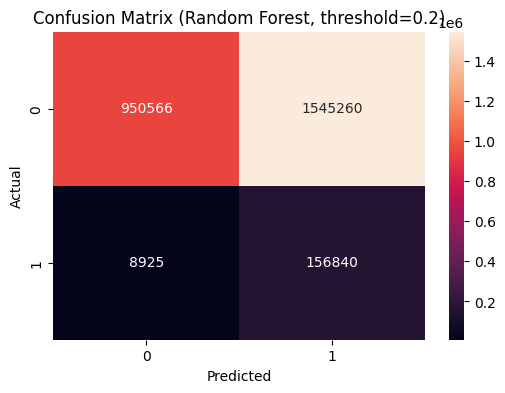

In [26]:
# Confusion matrix at a chosen threshold

from sklearn.metrics import confusion_matrix

THRESHOLD = 0.20  # adjust based on the table above

rf_preds_t = (rf_probs >= THRESHOLD).astype(int)
cm = confusion_matrix(y_val, rf_preds_t)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d")
plt.title(f"Confusion Matrix (Random Forest, threshold={THRESHOLD})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Confusion Matrix (Random Forest)

The confusion matrix summarizes how the Random Forest model performs when predicting reorder events at the selected probability threshold (0.20). The matrix shows the number of correctly and incorrectly classified observations for both classes.

True negatives represent products correctly predicted as not reordered, while true positives represent products correctly predicted as reordered. False positives occur when the model predicts a reorder that does not actually occur, and false negatives occur when a reorder event is missed.

Because reorder prediction is an imbalanced classification problem, analyzing the confusion matrix helps understand the trade-off between identifying reorder events and limiting incorrect predictions.

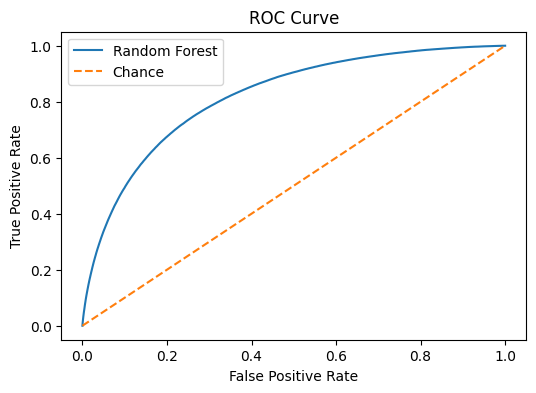

In [27]:
# ROC curve

from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_val, rf_probs)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="Random Forest")
plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

### ROC Curve

The ROC (Receiver Operating Characteristic) curve evaluates the model's ability to distinguish between reordered and non-reordered products across different classification thresholds.

The curve plots the True Positive Rate (Recall) against the False Positive Rate. A model with good predictive performance will produce a curve that moves toward the top-left corner of the plot, indicating high recall with a relatively low false positive rate.

The dashed diagonal line represents a random classifier. Since the Random Forest curve lies well above this baseline, it indicates that the model has meaningful predictive power in identifying reorder behavior.

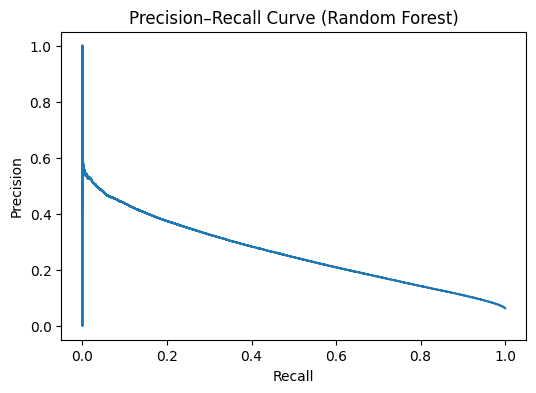

In [28]:
# Precision–Recall curve

from sklearn.metrics import precision_recall_curve

prec, rec, _ = precision_recall_curve(y_val, rf_probs)

plt.figure(figsize=(6,4))
plt.plot(rec, prec)
plt.title("Precision–Recall Curve (Random Forest)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

### Precision–Recall Curve

The Precision–Recall curve evaluates model performance specifically for the reordered class, which is the minority class in this dataset. This curve is particularly useful when working with imbalanced data.

Recall measures how many true reorder events the model successfully identifies, while precision measures how many predicted reorder events are actually correct.

The curve illustrates the trade-off between these two metrics. As recall increases, precision typically decreases because more predictions are made. This visualization helps determine the appropriate probability threshold depending on whether the goal is to capture more reorder events or to reduce false recommendations.

## Model Interpretation
### Feature Importance and Key Predictive Drivers

Feature importance is examined to identify which behavioral signals contribute most to reorder prediction. This supports interpretability and connects model outputs to actionable business strategy.

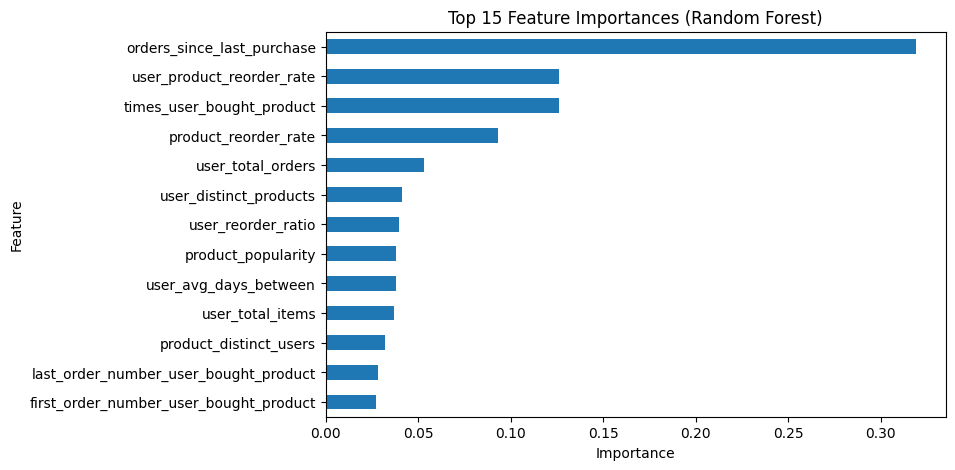

,0
orders_since_last_purchase,0.319278
user_product_reorder_rate,0.126143
times_user_bought_product,0.126135
product_reorder_rate,0.093102
user_total_orders,0.053265
user_distinct_products,0.040973
user_reorder_ratio,0.039799
product_popularity,0.038220
user_avg_days_between,0.038190
user_total_items,0.036930


In [29]:
# Feature importance

importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,5))
importances.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

importances.head(20)

### Feature Importance Analysis

The feature importance plot shows which variables contributed most to the Random Forest model’s predictions of whether a product will be reordered. Feature importance values represent the relative contribution of each feature to reducing prediction error across the decision trees in the model.

The most influential feature is **`orders_since_last_purchase`**, indicating that recency plays a major role in predicting reorder behavior. Products purchased more recently are generally more likely to be reordered. Other highly important features include **`user_product_reorder_rate`** and **`times_user_bought_product`**, which capture the strength of the relationship between a specific user and product. These features reflect customer loyalty and habitual purchasing patterns.

Product-level features such as **`product_reorder_rate`** and **`product_popularity`** also contribute to predictions, suggesting that some products are inherently more likely to be reordered across the customer base. Additionally, broader user behavior metrics such as **`user_total_orders`**, **`user_distinct_products`**, and **`user_reorder_ratio`** provide insight into general shopping habits and purchasing consistency.

Overall, the importance rankings show that the model relies heavily on **recency, frequency, and user–product interaction history**, which aligns with expected consumer purchasing behavior in grocery retail environments.

## Business Interpretation of Results

The models indicate that reorder behavior is driven primarily by user–product loyalty signals (purchase frequency and recency) as well as broader product-level popularity trends. Features such as how often a user purchases a product, how recently it was purchased, and how frequently the product is reordered by other users all contribute significantly to predicting future reorder behavior.

From an Instacart business perspective, the predicted reorder probability can support several strategic applications:

- personalized reorder suggestions and “Buy Again” ranking,
- retention-focused reminders for frequently purchased items,
- targeted promotions to encourage repeat purchase,
- demand planning through identifying likely repeat demand.

For example, if the model predicts a high probability that a customer will reorder a specific product, the platform could surface that item prominently in the user’s shopping interface or send reminder notifications. This improves the customer experience by reducing search time and increasing convenience. At the same time, these predictions can help retailers anticipate demand patterns, optimize inventory planning, and design marketing strategies that encourage repeat purchasing behavior.

## Exportation and Download

In [30]:
# Save and Downloading the model in notebook

import joblib

# Save trained model
joblib.dump(rf_model, "rf_reorder_model.joblib")

# Save feature column order
joblib.dump(list(X.columns), "rf_feature_columns.joblib")

print("Model and feature columns saved.")

from google.colab import files

files.download("rf_reorder_model.joblib")
files.download("rf_feature_columns.joblib")

Model and feature columns saved.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [31]:
# Export the feature tables and Download

user_features.to_csv("user_features.csv", index=False)
product_features.to_csv("product_features.csv", index=False)
user_product_features.to_csv("user_product_features.csv", index=False)

print("Feature tables exported.")

from google.colab import files

files.download("user_features.csv")
files.download("product_features.csv")
files.download("user_product_features.csv")

Feature tables exported.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
# Export product_name

# Load only product_id + product_name
products_name = pd.read_csv(f"{DATA_DIR}/products.csv", usecols=["product_id", "product_name"])

# Save a lightweight lookup table
products_name.to_csv("products_lookup.csv", index=False)

print(products_name.shape)
products_name.head()

(49688, 2)


,product_id,product_name
0,1,Chocolate Sandwich Cookies
1,2,All-Seasons Salt
2,3,Robust Golden Unsweetened Oolong Tea
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...
4,5,Green Chile Anytime Sauce


In [33]:
# Download products_lookup.csv

from google.colab import files
files.download("products_lookup.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Final Model Selection

Two models were evaluated in this project: **Logistic Regression** and **Random Forest**. Logistic Regression was used as a baseline model because of its simplicity and interpretability, while Random Forest was evaluated to capture more complex, nonlinear relationships between user behavior and product interactions.

The Logistic Regression model achieved a ROC-AUC score of **0.7622**, indicating reasonable predictive capability. However, due to the strong class imbalance in the dataset (most user–product pairs do not result in a reorder), the model struggled to correctly identify reordered products. While it performed well at predicting non-reorders, it had very low recall for actual reorder events.

The Random Forest model achieved a higher ROC-AUC score of **0.818**, demonstrating stronger predictive performance. The model improved the ability to detect reorder events and captured nonlinear relationships between important behavioral features such as purchase frequency, product popularity, and purchase recency.

In addition, Random Forest produced meaningful **feature importance rankings**, which helped identify the most influential factors driving reorder behavior. These insights were later used to support the business interpretation and dashboard visualizations.

Although Random Forest requires more computational resources than Logistic Regression, its improved predictive performance and ability to model complex interactions make it more suitable for this recommendation problem.

For these reasons, **Random Forest was selected as the final model and is used in the deployed Dash dashboard to generate reorder probability predictions and product recommendations.**

## Deployment Demonstration with Dash

To demonstrate how the trained machine learning model could be used in a real-world application, an interactive dashboard was developed using **Dash**.

Instead of simply entering a user ID and product ID, the dashboard simulates a small recommendation system workflow. After selecting a customer, the application loads the customer’s purchase history, scores each product using the trained **Random Forest model**, and visualizes the results.

The dashboard includes several components:

- **User KPI Panel** – displays key behavioral metrics for the selected customer such as:
  - total orders
  - reorder ratio
  - average days between orders
  - number of distinct products purchased

- **Purchase History Table** – a searchable and sortable table that shows products previously purchased by the user along with the model’s predicted reorder probability.

- **Top Reorder Recommendations** – a visualization of the products with the highest predicted probability of being reordered.

- **Promotion Candidates Panel** – identifies products that the model predicts the customer is likely to reorder but has not purchased recently. These items could be targeted with reminders, coupons, or promotions.

- **Prediction Detail Panel** – when a product is selected from the table, the dashboard displays:
  - predicted reorder probability
  - a probability gauge visualization
  - supporting behavioral signals such as purchase frequency and recency.

This dashboard demonstrates how the machine learning model can move beyond offline analysis and be integrated into a **decision-support tool for e-commerce platforms**. Retailers such as Instacart could use a similar system to power personalized reorder suggestions, targeted promotions, and demand forecasting.

The Dash application is implemented in a separate file (`app.py`) included with this project.

![Dash Dashboard Screenshot](dash_screenshot.png)

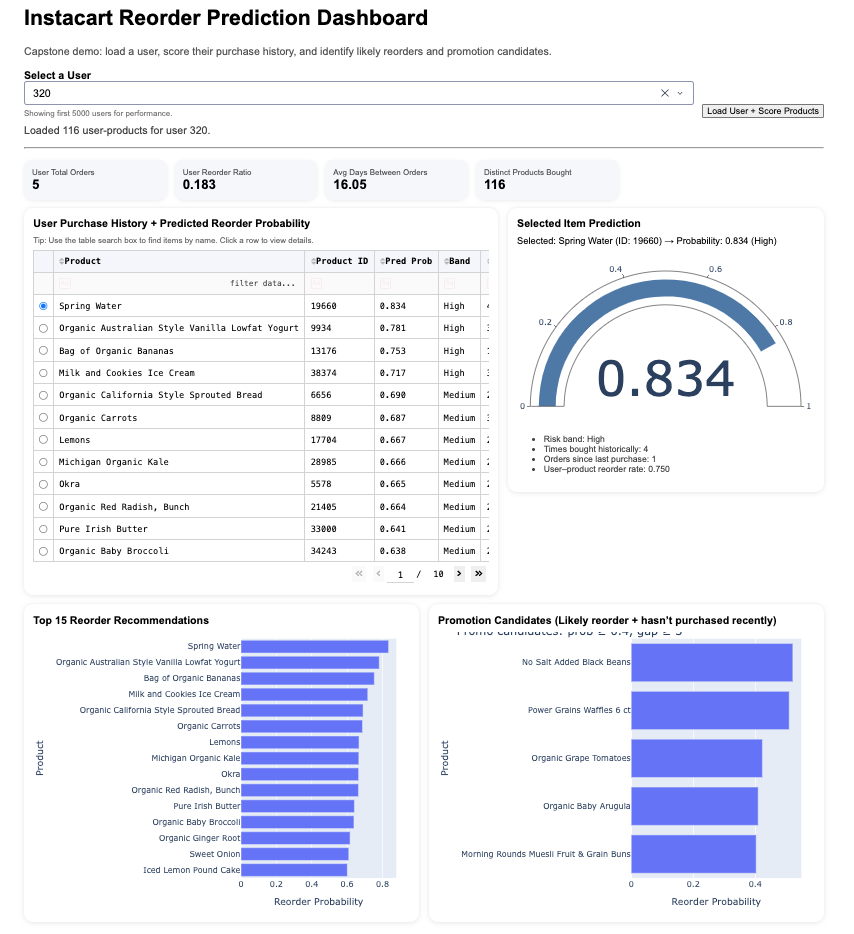

In [35]:
# Display Dash Screenshot

from IPython.display import Image
Image("dash_screenshot.png", width=900)

## Model Limitations

While the model performs well for identifying likely reorder behavior, there are several limitations that should be considered.

First, the dataset only captures historical purchase behavior and does not include other potentially important factors such as product pricing, promotions, seasonality, or customer preferences outside of the Instacart platform. These additional signals could significantly improve predictive performance.

Second, the dataset is highly imbalanced. Most user–product combinations do not result in a reorder, which makes the prediction problem challenging. Although techniques such as threshold tuning and evaluation with ROC and precision–recall metrics were used, the imbalance can still affect model performance.

Third, the engineered features rely primarily on behavioral aggregates such as purchase frequency, reorder rate, and recency. While these are strong predictors, they do not capture deeper product relationships or basket-level interactions between items.

Finally, the dashboard application is a simplified prototype meant to demonstrate model deployment. In a real production environment, the system would require a scalable data pipeline, model monitoring, and integration with live user interaction data.

## Future Work

Several improvements could further enhance the predictive performance and real-world applicability of this system.

One potential improvement would be incorporating additional contextual features such as promotions, discounts, seasonal demand patterns, or product categories. These variables could provide valuable signals about when a customer is more likely to reorder an item.

Another direction would be implementing more advanced machine learning models such as gradient boosting methods (XGBoost or LightGBM) or deep learning approaches that capture complex nonlinear relationships between users and products.

The recommendation system could also be expanded to include collaborative filtering or hybrid recommendation techniques that account for similarities between users and products.

From a deployment perspective, the dashboard could be extended into a fully interactive application that integrates directly with a database or API. This would allow real-time scoring of customer behavior and enable the system to continuously update predictions as new purchase data becomes available.

## Conclusion

This project demonstrated the development of a machine learning system for predicting whether a customer will reorder a product on an online grocery platform.

The analysis began with exploratory data analysis and feature engineering to capture important behavioral signals such as purchase frequency, recency, reorder rates, and product popularity. These features were then used to train classification models including Logistic Regression and Random Forest.

Model evaluation showed that the Random Forest model provided stronger predictive performance and better captured nonlinear relationships in the data. Feature importance analysis indicated that user–product interaction features, particularly purchase frequency and recency, were the most influential predictors of reorder behavior.

To demonstrate how the trained model could be used in practice, an interactive dashboard was built using Dash. The dashboard allows users to load a customer's purchase history, view predicted reorder probabilities, identify top recommended products, and detect promotion opportunities for items that are likely to be reordered but have not been purchased recently.

Overall, this project illustrates how machine learning models can be applied to real-world e-commerce recommendation problems and how predictive insights can be translated into actionable decision-support tools for businesses.

## Key Findings

- **User–product interaction features are the strongest predictors of reorder behavior.** Variables such as purchase frequency, reorder rate, and recency had the highest feature importance in the Random Forest model.

- **Random Forest outperformed Logistic Regression**, achieving a higher ROC-AUC score and improving the model’s ability to detect actual reorder events in an imbalanced dataset.

- **Customer loyalty patterns strongly influence reorder probability.** Products that a user frequently purchases or recently purchased are significantly more likely to be reordered.

- **The developed Dash dashboard demonstrates how machine learning predictions can support business decisions**, such as personalized reorder recommendations and targeted promotion opportunities for products customers are likely to purchase again.

## Running the Dash Application

The interactive dashboard used to demonstrate model deployment is implemented in the file `app.py`.

To run the dashboard locally:

1. Open a terminal in the project directory.
2. Install the required dependencies if necessary: pip install dash plotly pandas scikit-learn joblib
3. Run the following command: python app.py (MAC python3 app.py)
4. Open the following address in a web browser: http://127.0.0.1:8050

The dashboard will allow users to load a customer, view predicted reorder probabilities, explore recommended products, and identify potential promotion opportunities.


## Data Source

This project uses the **Instacart Online Grocery Shopping Dataset**, which contains anonymized customer purchase histories including product orders, reorder indicators, and order timing information.

Instacart. (2017). *Instacart Market Basket Analysis Dataset*.  
Available on Kaggle:  
https://www.kaggle.com/datasets/psparks/instacart-market-basket-analysis?utm_.com

The dataset was used to engineer behavioral features describing user purchasing patterns and product popularity, which were then used to train the reorder prediction models.